# Common gotcha's to create publication ready illustrations. 

The following general consideration might be relevant to create appealing illustration using _plot-misc_ :
* Dimensions
* Shape outline
* Tick locations versus tick labels
* Text formatting and axes labeling
* Illustration titles and notes

---

## Dimensions
The first step in creating an illustration is to consider the size at which it will be displayed. For example, journal articles typically use either single- or double-column layouts, corresponding to widths of approximately 9 and 18 centimetres. This implies that the width of an illustration should usually be designed to fit within either 7–9 or 16–18 centimetres.

By contrast, a PowerPoint slide is at most about 25 × 19 centimetres. As a result, an image optimised for a manuscript may not always be suited for use in a slide deck, and it maybe necessary to develop multiple versions of the same illustration depending on its intended context.

### Dimensions for multipanel plots
For illustrations consisting of multiple panels, the relative dimensions of the panels are also important. For example, consider the two-panel forest plot shown below, generated with I) equal panel heights and II) panel heights proportional to the number of rows in each panel.

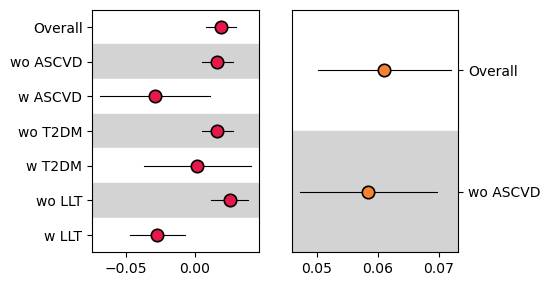

In [1]:
# ##### Equal panel heights
import matplotlib.pyplot as plt
import plot_misc.forest as forest
import plot_misc.example_data.examples as examples
from matplotlib.gridspec import GridSpec

# Getting the data
CMTOINCH = 1/2.54
POINT = 'coef'
LB = 'coef lower 95%'
UB = 'coef upper 95%'
YLABEL = 'Model'
COMP = 'Comparison'
data = examples.load_mace_associations()
table1 = data.loc[data.covariate == "LDL-C (mmol/L)",  ]
table2 = data.loc[data.covariate != "LDL-C (mmol/L)", ].iloc[0:2]

# Add y-coordinates
table1 = forest.set_y_coordinates(
    table1,
)
table2 = forest.set_y_coordinates(
    table2, 
)

# Common constants 
CI_SIZE=0.80
SCOL = 80
EDGECOLOUR='black'

# A multipanel figure using gridspec
fig = plt.figure(figsize=(12*CMTOINCH, 8*CMTOINCH))
gs = GridSpec(nrows=1, ncols=2,
              figure=fig, wspace=0.2,
             )

ax1 = fig.add_subplot(gs[(0,0)])
ax2 = fig.add_subplot(gs[(0,1)])

# the actual plotting
forest_obj1 = forest.ForestPlot(
    data=table1, x_col=POINT, lb_col=LB, ub_col=UB, g_col=YLABEL,
    ax=ax1,
)
forest_obj1.plot(
    c_col='col',s_size_col=SCOL, ci_lwd=CI_SIZE, 
    ci_colour=EDGECOLOUR,
    span=True,
    reverse_y=True, 
    kwargs_scatter_dict={'edgecolors':EDGECOLOUR, 'linewidth':1.2, 'zorder':2},
    kwargs_plot_ci_dict={'zorder':1},
    )


forest_obj2 = forest.ForestPlot(
    data=table2, x_col=POINT, lb_col=LB, ub_col=UB, g_col=YLABEL,
    ax=ax2,
)
forest_obj2.plot(
    c_col='col',s_size_col=SCOL, ci_lwd=CI_SIZE, 
    ci_colour=EDGECOLOUR,
    span=True,
    reverse_y=True, 
    kwargs_scatter_dict={'edgecolors':EDGECOLOUR, 'linewidth':1.2, 'zorder':2},
    kwargs_plot_ci_dict={'zorder':1},
    )
ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")

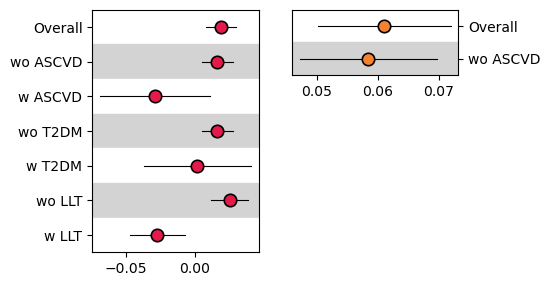

In [2]:
# ##### Proportiona panel heights
fig = plt.figure(figsize=(12*CMTOINCH, 8*CMTOINCH))
mrow = max(table1.shape[0], table2.shape[0])
gs = GridSpec(nrows=mrow, ncols=2,
              figure=fig, wspace=0.2,
             )

ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0:2, 1])

# the actual plotting
forest_obj1 = forest.ForestPlot(
    data=table1, x_col=POINT, lb_col=LB, ub_col=UB, g_col=YLABEL,
    ax=ax1,
)
forest_obj1.plot(
    c_col='col',s_size_col=SCOL, ci_lwd=CI_SIZE, 
    ci_colour=EDGECOLOUR,
    span=True,
    reverse_y=True, 
    kwargs_scatter_dict={'edgecolors':EDGECOLOUR, 'linewidth':1.2, 'zorder':2},
    kwargs_plot_ci_dict={'zorder':1},
    )


forest_obj2 = forest.ForestPlot(
    data=table2, x_col=POINT, lb_col=LB, ub_col=UB, g_col=YLABEL,
    ax=ax2,
)
forest_obj2.plot(
    c_col='col',s_size_col=SCOL, ci_lwd=CI_SIZE, 
    ci_colour=EDGECOLOUR,
    span=True,
    reverse_y=True, 
    kwargs_scatter_dict={'edgecolors':EDGECOLOUR, 'linewidth':1.2, 'zorder':2},
    kwargs_plot_ci_dict={'zorder':1},
    )
ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")

## Shape outline

Shape outlines improve figure clarity and readability. They make elements visible against complex backgrounds, and distinguish overlapping points in scatter plots or bar charts.  
Even subtle, slightly darker edges can dramatically enhance interpretability without cluttering the visual. 

To illustrate this consider the bar charts and heatmaps below. 

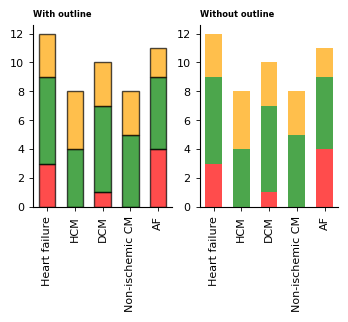

In [3]:
# #### Barchart example
import matplotlib.pyplot as plt
import plot_misc.barchart as barchart
import plot_misc.example_data.examples as examples

# import example data
table = examples.load_barchart_data()
table = table.T

# constants
COLOURS = ['red', 'green', 'orange']
EDGECOLOUR = 'black'
TICKS_WD = 0.6
CMTOINCH = 1/2.54
LABELS = 'labels'

# Adding the index as a column
table['labels'] = table.index
table=table.loc[['Heart failure', 'HCM', 'DCM', 'Non-ischemic CM', 'AF']]

# Create figure and axes
fig = plt.figure(figsize=(10*CMTOINCH, 6*CMTOINCH))
gs = GridSpec(nrows=1, ncols=2,
              figure=fig, wspace=0.2,
             )

ax1 = fig.add_subplot(gs[(0,0)])
ax2 = fig.add_subplot(gs[(0,1)])


# Creating the illustrations
_, ax1 = barchart.stack_bar(table, label=LABELS, columns=table.columns[:-1].to_list(),
                        wd=0.6, edgecolor=EDGECOLOUR, colours=COLOURS, ax=ax1,
                        **{'linewidth':1}
                        )

_, ax2 = barchart.stack_bar(table, label=LABELS, columns=table.columns[:-1].to_list(),
                        wd=0.6, edgecolor=EDGECOLOUR, colours=COLOURS, ax=ax2,
                        **{'linewidth':0}
                           )

# setting ticks and labels
for ax in [ax1, ax2]:
    ax.set_xlim(-0.5,table.shape[0]-0.5)
    ax.tick_params(axis="x", labelsize=8.0, length=3, width=TICKS_WD, rotation=90)
    ax.tick_params(axis="y", labelsize=8.0, length=3, width=TICKS_WD, rotation=0)

_ = ax1.set_title("With outline", fontsize=6, fontweight="bold",  color="black",loc="left",)    
_ = ax2.set_title("Without outline", fontsize=6, fontweight="bold",  color="black", loc="left",)    

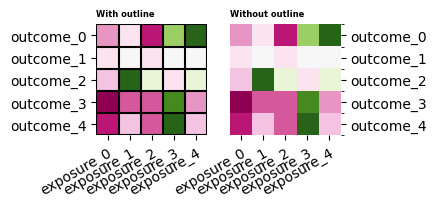

In [4]:
# #### Heatmaps
import matplotlib.pyplot as plt
import plot_misc.utils.utils as pm_utils
import plot_misc.heatmap as heatmap
import plot_misc.example_data.examples as examples

# import example data and subset 
matrix = examples.load_heatmap_data()
mat_ = matrix.iloc[0:5, 0:5]

# CMAP
cmap = plt.get_cmap("PiYG", 13)
bounds = [-8, -6, -4, -2, 0, 2, 4, 6, 8]
norm = pm_utils.MidpointNormalize(vcenter = 0, vmin=-8, vmax=8)

# constants
CMTOINCH = 1/2.54

PAD=1.5
COLB= 'b'
LENT=3

# Create figure and axes
fig = plt.figure(figsize=(8*CMTOINCH, 4*CMTOINCH))
gs = GridSpec(nrows=1, ncols=2, figure=fig, wspace=0.2,)
ax1 = fig.add_subplot(gs[(0,0)])
ax2 = fig.add_subplot(gs[(0,1)])

_ = heatmap.heatmap(data=mat_, row_labels=mat_.index.to_list(),
                           col_labels=mat_.columns.to_list(), ax=ax1,
                           cmap=cmap, grid_linewidth=1.5, grid_col='black',
                           )
_ = heatmap.heatmap(data=mat_, row_labels=mat_.index.to_list(),
                           col_labels=mat_.columns.to_list(), ax=ax2,
                           cmap=cmap ,grid_linewidth=0,
                           )
ax2.yaxis.set_ticks_position("right")
ax2.yaxis.set_label_position("right")
_ = ax1.set_title("With outline", fontsize=6, fontweight="bold",  color="black",loc="left",)    
_ = ax2.set_title("Without outline", fontsize=6, fontweight="bold",  color="black", loc="left",) 

## Tick locations versus tick labels
For some illustrations, it is important to distinguish between tick locations and tick labels. This is particularly relevant for plots with categorical variables, where tick positions and labels will not coincide.  

Similarly, ratio estimates (e.g., odds ratios or hazard ratios) are often plotted on a logarithmic scale to achieve symmetry about one. However, labels are usually easier to interpret on the original ratio scale rather than the transformed logarithmic scale.  

See below for an example using forest plots.

**TODO!**

## Text formatting and axes labeling
Be conscious of mapping raw column labels to publication-ready strings, including relevant units where appropriate.  

Similarly, for plot elements consisting of string representations of floats, ensure these are preprocessed. For example, include trailing zeros rather than relying on rounded floats, which typically remove redundant zeros.

In [5]:
# ### raw string to publication labels
import re
raw = "age_years"
re.sub(r"_(\w+)", r" (\1)", raw).capitalize()

'Age (years)'

In [6]:
# ### format numerical as strings
from plot_misc.utils.formatting import format_estimates
format_estimates(point = 0.80001, lower = 0.6234, upper=1.0346)

'0.80 (0.62; 1.03)'

# Informative figure titles and notes

Figure titles should be descriptive about what the figure represents and provide more detail than describing the general plotting type.

So rather than writing "__Forest plot__", write "__The associations between plasma proteins per standard deviation on incidence coronary heart disease__". 

Additionally, it is good practice to provide further details in the figure note. For example the following information is often included in the note:
* The source of the data (e.g. Analyses based on the All of US cohort),
* The sample size (e.g. based on 100 people free of coronary heart disease at the time of proteomics measurements),
* A brief recap of the analytical methods (e.g. Hazard ratios were derived from a Cox proporitional hazards regression model),
* An alphabetised list of abbreviations (e.g., CHD, coronary heart disease; HF, heart failure; Q, Q-statistic)